In [1]:
import pandas as pd
import numpy as np
from scipy import stats

# to visualize the data
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
# ignore warnings   
import warnings
warnings.filterwarnings('ignore')

## Loading Data

In [2]:
file = "/Users/fizx/Documents/Faiz/projects/Project 4/FRED-MD_2024m12.csv"
dataframe = pd.read_csv(file)

In [3]:
df = dataframe.copy()

In [4]:
for col in df.columns:
    print(col)

sasdate
RPI
W875RX1
DPCERA3M086SBEA
CMRMTSPLx
RETAILx
INDPRO
IPFPNSS
IPFINAL
IPCONGD
IPDCONGD
IPNCONGD
IPBUSEQ
IPMAT
IPDMAT
IPNMAT
IPMANSICS
IPB51222S
IPFUELS
CUMFNS
HWI
HWIURATIO
CLF16OV
CE16OV
UNRATE
UEMPMEAN
UEMPLT5
UEMP5TO14
UEMP15OV
UEMP15T26
UEMP27OV
CLAIMSx
PAYEMS
USGOOD
CES1021000001
USCONS
MANEMP
DMANEMP
NDMANEMP
SRVPRD
USTPU
USWTRADE
USTRADE
USFIRE
USGOVT
CES0600000007
AWOTMAN
AWHMAN
HOUST
HOUSTNE
HOUSTMW
HOUSTS
HOUSTW
PERMIT
PERMITNE
PERMITMW
PERMITS
PERMITW
ACOGNO
AMDMNOx
ANDENOx
AMDMUOx
BUSINVx
ISRATIOx
M1SL
M2SL
M2REAL
BOGMBASE
TOTRESNS
NONBORRES
BUSLOANS
REALLN
NONREVSL
CONSPI
S&P 500
S&P div yield
S&P PE ratio
FEDFUNDS
CP3Mx
TB3MS
TB6MS
GS1
GS5
GS10
AAA
BAA
COMPAPFFx
TB3SMFFM
TB6SMFFM
T1YFFM
T5YFFM
T10YFFM
AAAFFM
BAAFFM
TWEXAFEGSMTHx
EXSZUSx
EXJPUSx
EXUSUKx
EXCAUSx
WPSFD49207
WPSFD49502
WPSID61
WPSID62
OILPRICEx
PPICMM
CPIAUCSL
CPIAPPSL
CPITRNSL
CPIMEDSL
CUSR0000SAC
CUSR0000SAD
CUSR0000SAS
CPIULFSL
CUSR0000SA0L2
CUSR0000SA0L5
PCEPI
DDURRG3M086SBEA
DNDGRG3M086SBEA
DSERRG

In [8]:
cols_to_keep = ['sasdate', 'CPIAUCSL', 'UNRATE', 'FEDFUNDS']

df = df[cols_to_keep]

In [11]:
df.head()

,sasdate,CPIAUCSL,UNRATE,FEDFUNDS
2,2/1/1959,29.00,5.9,2.43
3,3/1/1959,28.97,5.6,2.80
4,4/1/1959,28.98,5.2,2.96
5,5/1/1959,29.04,5.1,2.90
6,6/1/1959,29.11,5.0,3.39


In [10]:
df = df.iloc[1:]

In [12]:
df['sasdate'] = pd.to_datetime(df['sasdate'])

In [13]:
house = pd.read_csv("/Users/fizx/Downloads/CSUSHPINSA.csv")

In [14]:
house['observation_date'] = pd.to_datetime(house['observation_date'])
house.head()

,observation_date,CSUSHPINSA
0,1987-01-01,63.733
1,1987-02-01,64.132
2,1987-03-01,64.468
3,1987-04-01,64.972
4,1987-05-01,65.547


In [15]:
df = df.merge(
    house,
    left_on='sasdate',
    right_on='observation_date',
    how='inner'
)

df = df.rename(columns={'CSUSHPINSA': 'house_price_index'})
df = df.drop(columns=['observation_date'])

In [16]:
df.head()

,sasdate,CPIAUCSL,UNRATE,FEDFUNDS,house_price_index
0,1987-01-01,111.4,6.6,6.43,63.733
1,1987-02-01,111.8,6.6,6.10,64.132
2,1987-03-01,112.2,6.6,6.13,64.468
3,1987-04-01,112.7,6.3,6.37,64.972
4,1987-05-01,113.0,6.3,6.85,65.547


In [17]:
df = df.rename(columns={
    'sasdate': 'date',
    'CPIAUCSL': 'CPI',
    'UNRATE': 'unemployment_rate',
    'FEDFUNDS': 'interest_rate'

})

In [18]:
df.head()

,date,CPI,unemployment_rate,interest_rate,house_price_index
0,1987-01-01,111.4,6.6,6.43,63.733
1,1987-02-01,111.8,6.6,6.10,64.132
2,1987-03-01,112.2,6.6,6.13,64.468
3,1987-04-01,112.7,6.3,6.37,64.972
4,1987-05-01,113.0,6.3,6.85,65.547


In [19]:
df['inflation_rate'] = df['CPI'].pct_change(12) * 100

In [20]:
df[['date', 'CPI', 'inflation_rate']].head(15)

,date,CPI,inflation_rate
0,1987-01-01,111.4,NaN
1,1987-02-01,111.8,NaN
2,1987-03-01,112.2,NaN
3,1987-04-01,112.7,NaN
4,1987-05-01,113.0,NaN
5,1987-06-01,113.5,NaN
6,1987-07-01,113.8,NaN
7,1987-08-01,114.3,NaN
8,1987-09-01,114.7,NaN
9,1987-10-01,115.0,NaN


In [21]:
df = df.dropna().reset_index(drop=True)

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 443 entries, 0 to 442
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   date               443 non-null    datetime64[ns]
 1   CPI                443 non-null    float64       
 2   unemployment_rate  443 non-null    float64       
 3   interest_rate      443 non-null    float64       
 4   house_price_index  443 non-null    float64       
 5   inflation_rate     443 non-null    float64       
dtypes: datetime64[ns](1), float64(5)
memory usage: 20.9 KB


In [24]:
df['house_price_inflation'] = df['house_price_index'].pct_change(12) * 100

In [25]:
df.corr()

,date,CPI,unemployment_rate,interest_rate,house_price_index,inflation_rate,house_price_inflation
date,1.000000,0.989288,-0.113528,-0.652242,0.916753,-0.135112,0.192264
CPI,0.989288,1.000000,-0.141857,-0.582436,0.949399,-0.054100,0.176954
unemployment_rate,-0.113528,-0.141857,1.000000,-0.405098,-0.279089,-0.332184,-0.441715
interest_rate,-0.652242,-0.582436,-0.405098,1.000000,-0.401500,0.421027,-0.052065
house_price_index,0.916753,0.949399,-0.279089,-0.401500,1.000000,0.130774,0.283027
inflation_rate,-0.135112,-0.054100,-0.332184,0.421027,0.130774,1.000000,0.278688
house_price_inflation,0.192264,0.176954,-0.441715,-0.052065,0.283027,0.278688,1.000000


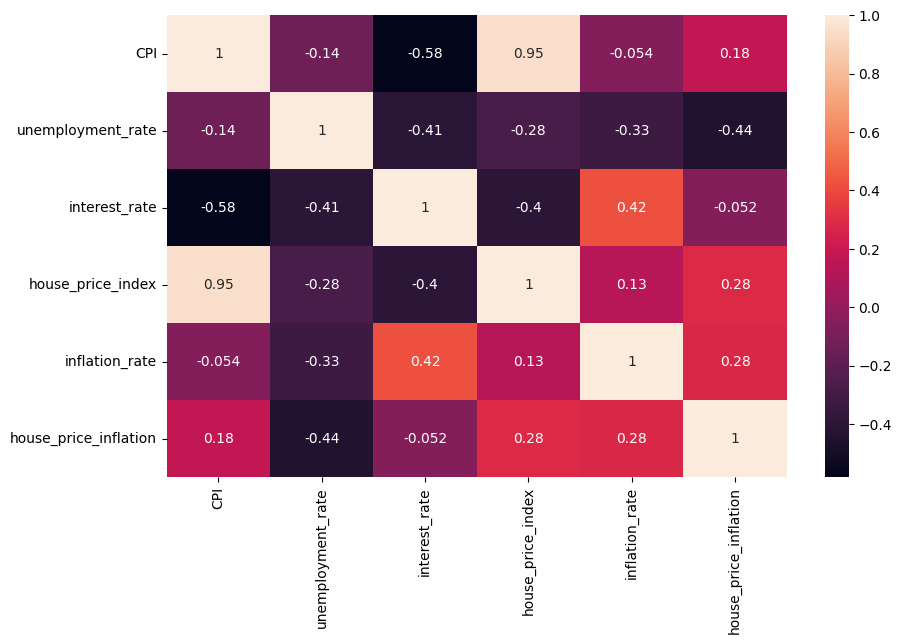

In [26]:
plt.figure(figsize=(10,6))
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True)
plt.show() 

In [27]:
df.describe()

,date,CPI,unemployment_rate,interest_rate,house_price_index,inflation_rate,house_price_inflation
count,443,443.000000,443.000000,443.000000,443.000000,443.000000,431.000000
mean,2006-06-01 08:53:05.553047424,202.155147,5.699097,3.138217,149.568790,2.795494,4.450532
min,1988-01-01 00:00:00,116.000000,3.400000,0.050000,68.583000,-1.958761,-12.751345
25%,1997-03-16 12:00:00,159.850000,4.450000,0.350000,84.115500,1.739010,1.626194
50%,2006-06-01 00:00:00,201.800000,5.400000,2.980000,144.272000,2.651779,4.605482
75%,2015-08-16 12:00:00,237.654500,6.500000,5.300000,182.733500,3.450880,7.816367
max,2024-11-01 00:00:00,316.441000,14.800000,9.850000,325.668000,8.989744,20.779923
std,NaN,51.109778,1.703589,2.634218,67.203483,1.626651,5.960769


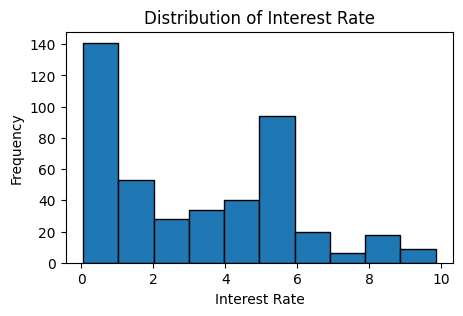

In [28]:
plt.figure(figsize=(5,3))
plt.hist(df['interest_rate'], bins=10, edgecolor='black')
plt.xlabel('Interest Rate')
plt.ylabel('Frequency')
plt.title('Distribution of Interest Rate')
plt.show()

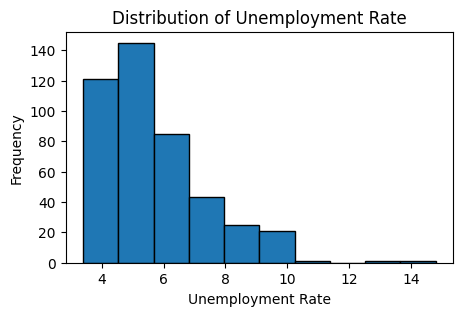

In [29]:
plt.figure(figsize=(5,3))
plt.hist(df['unemployment_rate'], bins=10, edgecolor='black')
plt.xlabel('Unemployment Rate')
plt.ylabel('Frequency')
plt.title('Distribution of Unemployment Rate')
plt.show()

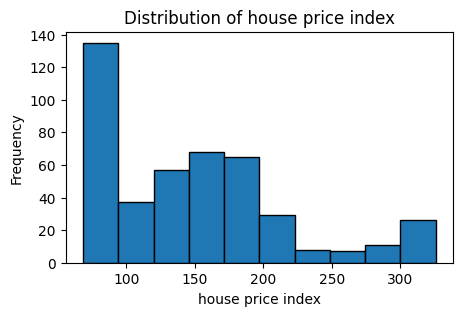

In [30]:
plt.figure(figsize=(5,3))
plt.hist(df['house_price_index'], bins=10, edgecolor='black')
plt.xlabel('house price index')
plt.ylabel('Frequency')
plt.title('Distribution of house price index')
plt.show()

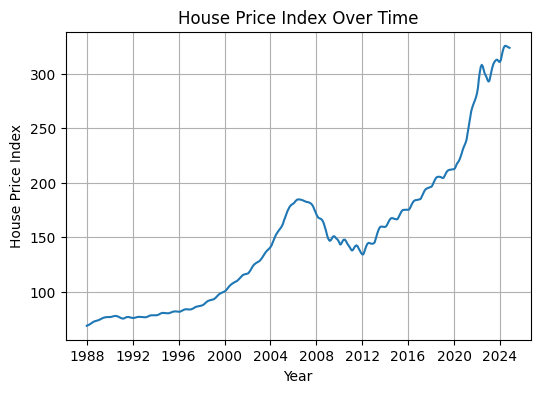

In [31]:
plt.figure(figsize=(6,4))
plt.plot(df['date'], df['house_price_index'])
plt.xlabel('Year')
plt.ylabel('House Price Index')
plt.title('House Price Index Over Time')
plt.grid(True)
plt.show()

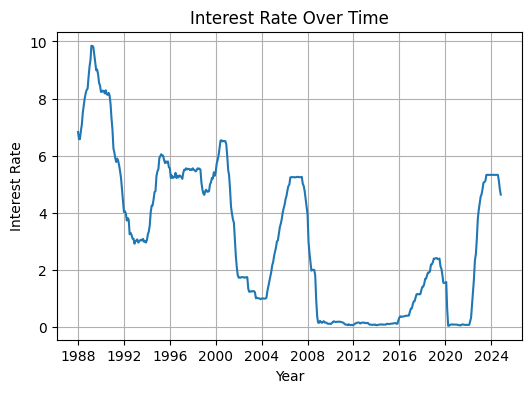

In [32]:
plt.figure(figsize=(6,4))
plt.plot(df['date'], df['interest_rate'])
plt.xlabel('Year')
plt.ylabel('Interest Rate')
plt.title('Interest Rate Over Time')
plt.grid(True)
plt.show()

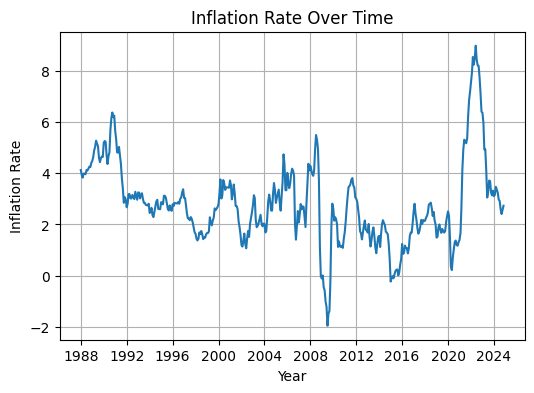

In [33]:
plt.figure(figsize=(6,4))
plt.plot(df['date'], df['inflation_rate'])
plt.xlabel('Year')
plt.ylabel('Inflation Rate')
plt.title('Inflation Rate Over Time')
plt.grid(True)
plt.show()

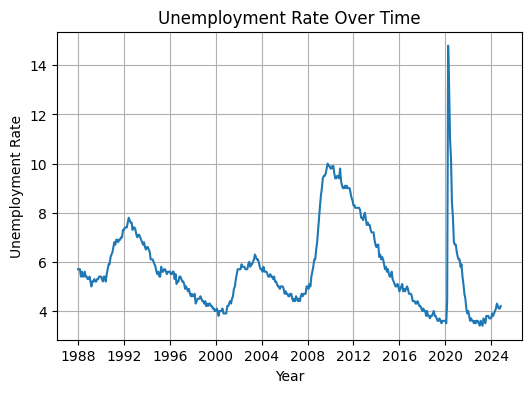

In [72]:
plt.figure(figsize=(6,4))
plt.plot(df['date'], df['unemployment_rate'])
plt.xlabel('Year')
plt.ylabel('Unemployment Rate')
plt.title('Unemployment Rate Over Time')
plt.grid(True)
plt.show()

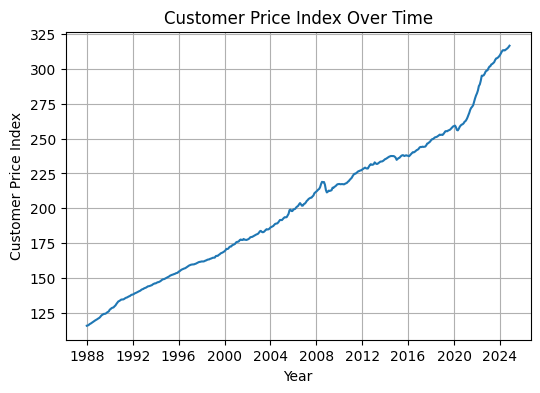

In [34]:
plt.figure(figsize=(6,4))
plt.plot(df['date'], df['CPI'])
plt.xlabel('Year')
plt.ylabel('Customer Price Index')
plt.title('Customer Price Index Over Time')
plt.grid(True)
plt.show()

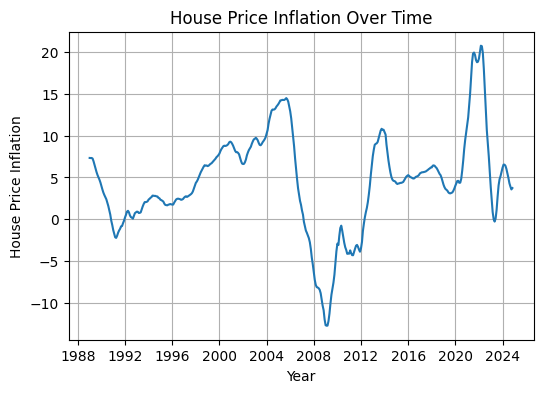

In [35]:
plt.figure(figsize=(6,4))
plt.plot(df['date'], df['house_price_inflation'])
plt.xlabel('Year')
plt.ylabel('House Price Inflation')
plt.title('House Price Inflation Over Time')
plt.grid(True)
plt.show()

# linear Regression

## The affects of lagged Interest rate, and Unemployment rate on Inflation rate

In [116]:
# keep only what we need
df_lr = df[['date', 'inflation_rate', 'unemployment_rate', 'interest_rate']].dropna()

# optional: add lag (recommended)
df_lr['fed_funds_lag24'] = df_lr['interest_rate'].shift(24)
df_lr = df_lr.dropna()

In [117]:
X = df_lr[['unemployment_rate', 'fed_funds_lag24']]
y = df_lr['inflation_rate']

In [118]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

In [119]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [120]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

mae, rmse

(1.7540051362197795, np.float64(2.626147714884461))

In [121]:
pd.Series(model.coef_, index=X.columns)

unemployment_rate   -0.147008
fed_funds_lag24      0.176263
dtype: float64

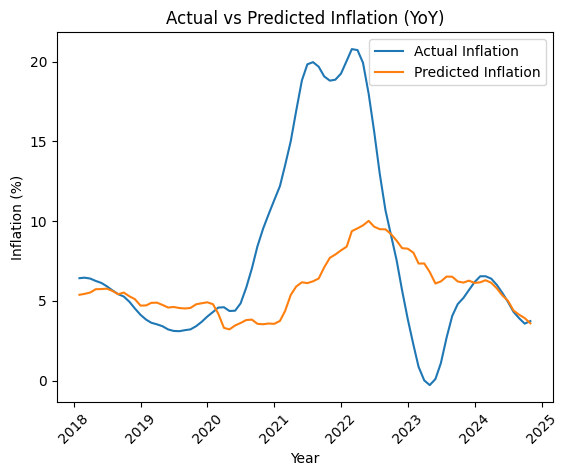

In [164]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(dates_test, y_test.values, label="Actual Inflation")
plt.plot(dates_test, y_pred, label="Predicted Inflation")
plt.legend()
plt.title("Actual vs Predicted Inflation (YoY)")
plt.xlabel("Year")
plt.ylabel("Inflation (%)")
plt.xticks(rotation=45)
plt.show()

## various scenarios

In [136]:
scenarios = pd.DataFrame({
    'unemployment_rate': [2, 4, 6],      # low, medium, high unemployment
    'fed_funds_lag24':   [2, 4, 6]       # accommodative → tight policy
}, index=[
    'Strong economy',
    'Moderate slowdown',
    'Recession scenario'
])

In [137]:
scenarios['predicted_inflation'] = model.predict(scenarios)
scenarios

,unemployment_rate,fed_funds_lag24,predicted_inflation
Strong economy,2,2,2.792629
Moderate slowdown,4,4,2.851139
Recession scenario,6,6,2.909649


In [147]:
scenarios = pd.DataFrame({
    'unemployment_rate': [4.0, 4.0, 4.0],
    'fed_funds_lag24':   [3.0, 4.5, 6.0]
}, index=[
    'Constant unemployment – low interest rate',
    'Constant unemployment – moderate interest rate',
    'Constant unemployment – high interest rate',
])

scenarios1 = pd.DataFrame({
    'unemployment_rate': [3.0, 4.5, 6.0],
    'fed_funds_lag24':   [4.0, 4.0, 4.0]
}, index=[
    'Constant interest rate – low unemployment',
    'Constant interest rate – moderate unemployment',
    'Constant interest rate – high unemployment'
])

In [148]:
scenarios['pred_house_price_inflation'] = model.predict(
    scenarios[features]
)

scenarios1['pred_house_price_inflation'] = model.predict(
    scenarios1[features]
)

In [149]:
final_scenarios = pd.concat([
    scenarios.assign(scenario_type='Constant unemployment'),
    scenarios1.assign(scenario_type='Constant interest rate')
])

final_scenarios

,unemployment_rate,fed_funds_lag24,pred_house_price_inflation,scenario_type
Constant unemployment – low interest rate,4.0,3.0,2.674876,Constant unemployment
Constant unemployment – moderate interest rate,4.0,4.5,2.939270,Constant unemployment
Constant unemployment – high interest rate,4.0,6.0,3.203664,Constant unemployment
Constant interest rate – low unemployment,3.0,4.0,2.998147,Constant interest rate
Constant interest rate – moderate unemployment,4.5,4.0,2.777635,Constant interest rate
Constant interest rate – high unemployment,6.0,4.0,2.557124,Constant interest rate


# The affects of Inlation rate and Interest rate on the Inflation rate of House Price    

In [150]:
df_lr = df[['date', 'house_price_inflation', 'inflation_rate', 'interest_rate']].dropna()

# add lag for interest rate (important)
df_lr['interest_rate_lag24'] = df_lr['interest_rate'].shift(24)
df_lr = df_lr.dropna()

In [151]:
X = df_lr[['inflation_rate', 'interest_rate_lag24']]
y = df_lr['house_price_inflation']

In [152]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

In [153]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [154]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

mae, rmse

(3.8360538224429033, np.float64(5.7416755681284455))

In [155]:
import pandas as pd

pd.Series(model.coef_, index=X.columns)

inflation_rate         0.661220
interest_rate_lag24   -0.617567
dtype: float64

In [161]:
# assuming df_lr contains 'date' and you split without shuffling
dates_test = df_lr.loc[y_test.index, 'date']

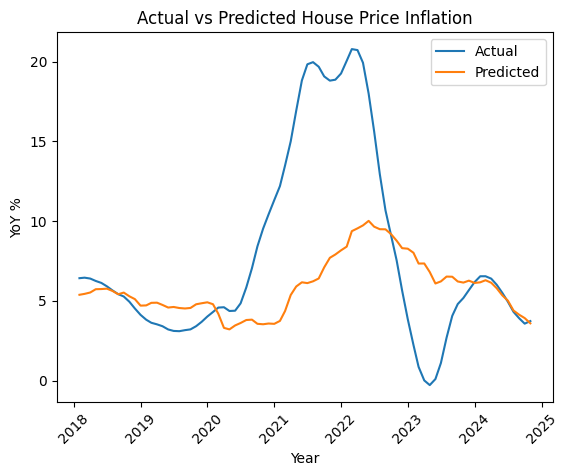

In [163]:
plt.figure()
plt.plot(dates_test, y_test.values, label="Actual")
plt.plot(dates_test, y_pred, label="Predicted")
plt.legend()
plt.title("Actual vs Predicted House Price Inflation")
plt.xlabel("Year")
plt.ylabel("YoY %")
plt.xticks(rotation=45)
plt.show()

In [159]:
scenarios = pd.DataFrame({
    "inflation_rate": [3, 4, 6, 4, 4, 6],
    "interest_rate_lag24": [2,2,2, 3, 5, 5],
}, index=[
    "Low inflation, low rates",
    "Moderate inflation, low rates",
    "High inflation, low rates",
    "Moderate inflation, moderate rates",
    "Moderate inflation, high rates",
    "High inflation, high rates",
])

scenarios["pred_house_price_inflation"] = model.predict(scenarios)
scenarios

,inflation_rate,interest_rate_lag24,pred_house_price_inflation
"Low inflation, low rates",3,2,4.866620
"Moderate inflation, low rates",4,2,5.527840
"High inflation, low rates",6,2,6.850281
"Moderate inflation, moderate rates",4,3,4.910274
"Moderate inflation, high rates",4,5,3.675141
"High inflation, high rates",6,5,4.997581


In [160]:
df.to_csv('FRED_clean')